C:\Users\Acer\AppData\Local\Temp\ipykernel_11164\2886742678.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
C:\Users\Acer\AppData\Local\Temp\ipykernel_11164\2886742678.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=class_counts.values, palette=colors)


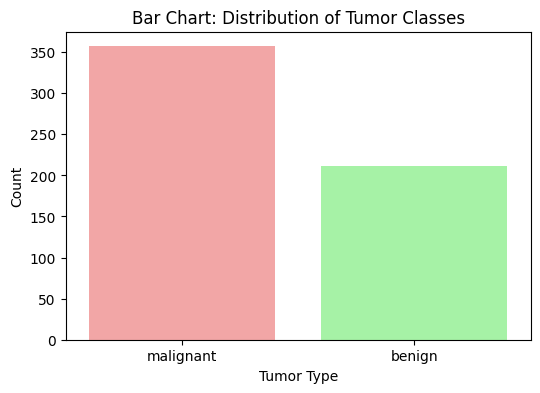

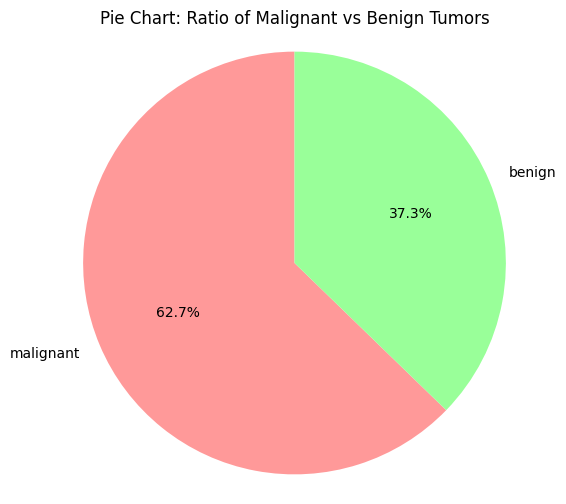

C:\Users\Acer\AppData\Local\Temp\ipykernel_11164\2886742678.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=colors)


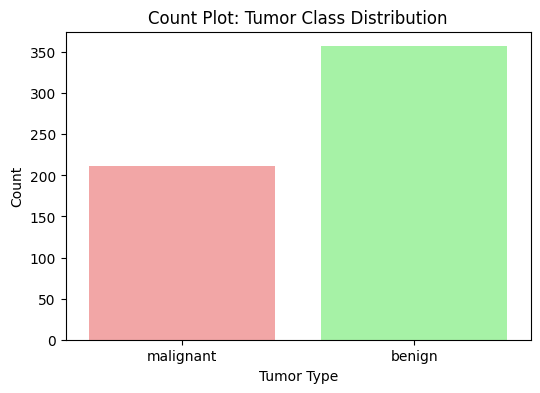

Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
 [[39  4]
 [ 1 70]]


In [1]:
# Step 1: Import required libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

import matplotlib.pyplot as plt
import seaborn as sns

# Count of each class
class_counts = pd.Series(y).value_counts()
labels = [data.target_names[0], data.target_names[1]]  # ['malignant', 'benign']
colors = ['#FF9999', '#99FF99']

# 1. Bar Chart
plt.figure(figsize=(6, 4))
sns.barplot(x=labels, y=class_counts.values, palette=colors)
plt.title('Bar Chart: Distribution of Tumor Classes')
plt.ylabel('Count')
plt.xlabel('Tumor Type')
plt.show()

# 2. Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Pie Chart: Ratio of Malignant vs Benign Tumors')
plt.axis('equal')
plt.show()

# 3. Count Plot (optional alternative)
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette=colors)
plt.xticks([0, 1], labels)
plt.title('Count Plot: Tumor Class Distribution')
plt.ylabel('Count')
plt.xlabel('Tumor Type')
plt.show()


# Step 3: Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Initialize and train the Logistic Regression classifier
logreg = LogisticRegression(max_iter=10000)  # increase max_iter to ensure convergence
logreg.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = logreg.predict(X_test)

# Step 6: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
